#🌟 **Exercises XP**

### 1. **Preprocess the Data:**

- Load the IMDB dataset using Keras.

In [1]:
# Import the necessary librairies
import os
import zipfile
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split


In [2]:
zip_path = "IMDB Dataset.zip"  # Name of the download file
extract_path = "Imdb"  # destination file

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [3]:
import pandas as pd

df = pd.read_csv('Imdb/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
from tensorflow.keras.preprocessing.text import Tokenizer

# We create a tokenizer that only keeps the 10,000 most frequent words
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(df['review'])  # learn vocabulary on our reviews

# transform each sentence into a list of indices (integers)
sequences = tokenizer.texts_to_sequences(df['review'])

print(sequences[0])

[27, 4, 1, 79, 2102, 45, 1072, 12, 100, 147, 39, 307, 3184, 398, 474, 26, 3195, 33, 23, 203, 14, 11, 6, 621, 48, 596, 16, 68, 7, 7, 1, 86, 148, 12, 3241, 68, 42, 3184, 13, 92, 5398, 2, 134, 4, 570, 60, 268, 8, 203, 36, 1, 661, 139, 1740, 68, 11, 6, 21, 3, 119, 15, 1, 7888, 2333, 38, 11, 119, 2595, 54, 5911, 16, 5510, 5, 1479, 376, 38, 570, 92, 6, 3804, 8, 1, 360, 356, 4, 1, 661, 7, 7, 9, 6, 433, 3184, 14, 12, 6, 1, 358, 5, 1, 6813, 2538, 1064, 9, 2711, 1421, 20, 538, 32, 4636, 2468, 4, 1, 1208, 117, 29, 1, 7017, 25, 2970, 2, 391, 34, 6, 21, 299, 20, 1, 4910, 7364, 538, 6, 344, 5, 106, 8161, 5050, 7889, 2453, 2, 51, 34, 327, 9106, 7365, 2, 8697, 23, 110, 225, 243, 7, 7, 10, 58, 131, 1, 280, 1324, 4, 1, 119, 6, 693, 5, 1, 192, 12, 9, 269, 117, 79, 276, 589, 3024, 834, 180, 1320, 4161, 15, 2523, 1243, 834, 1443, 834, 887, 3184, 149, 954, 183, 1, 86, 398, 10, 123, 210, 3241, 68, 14, 34, 1637, 9, 13, 2239, 10, 413, 131, 10, 13, 1592, 15, 9, 18, 14, 10, 287, 51, 10, 1417, 3, 1280, 15, 3184, 

- Convert the sequences of integers into binary matrices using one-hot encoding.

In [5]:
def vectorize_sequences(sequences, dimension=10000):
    # Create an all-zero matrix of shape (len(sequences), dimension)
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1  #set specific indices of results[i] to 1s
    return results

In [6]:
X = vectorize_sequences(sequences, dimension=10000)


In [7]:
print(X)

[[0. 1. 1. ... 0. 0. 0.]
 [0. 1. 1. ... 0. 0. 0.]
 [0. 1. 1. ... 0. 0. 0.]
 ...
 [0. 1. 1. ... 0. 0. 0.]
 [0. 1. 1. ... 0. 0. 0.]
 [0. 1. 1. ... 0. 0. 0.]]


- Split the data into training, validation, and test sets.

In [8]:
y = df['sentiment'].values

In [9]:
print(y)

['positive' 'positive' 'positive' ... 'negative' 'negative' 'negative']


In [10]:
# Convert "positive"/"negative" → 1/0
y = (df["sentiment"] == "positive").astype("float32")


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


In [12]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Train: (40000, 10000), Val: (5000, 10000), Test: (5000, 10000)


### 2. Build the Model:




- Create a feedforward neural network with:
  - Two hidden layers using ReLU activation.
  - An output layer with a sigmoid activation for binary classification.
- Compile the model using the RMSprop optimizer, binary cross-entropy loss, and accuracy as the evaluation metric.

In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(16, activation='relu', input_shape=(10000,)))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### 3. **Train the Model:**

- Train the model on the training data for 20 epochs with a batch size of 512.
- Use the validation set to monitor performance during training.

In [15]:
# Reduce to 10,000 examples for X and y
X_train_small = X_train[:10000]
y_train_small = y_train[:10000]
X_val_small = X_val[:2000]
y_val_small = y_val[:2000]


In [16]:
history = model.fit(
    X_train_small, y_train_small,
    epochs=20,
    batch_size=512,
    validation_data=(X_val_small, y_val_small)
)


Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6679 - loss: 0.6252 - val_accuracy: 0.8415 - val_loss: 0.4430
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8768 - loss: 0.3843 - val_accuracy: 0.8710 - val_loss: 0.3499
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9237 - loss: 0.2717 - val_accuracy: 0.8800 - val_loss: 0.3181
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9376 - loss: 0.2165 - val_accuracy: 0.8690 - val_loss: 0.3351
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9451 - loss: 0.1809 - val_accuracy: 0.8820 - val_loss: 0.3033
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9576 - loss: 0.1446 - val_accuracy: 0.8675 - val_loss: 0.3174
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9711 - loss: 0.1167 - val_accuracy: 0.8740 - val_loss: 0.3450
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9786 - loss: 0.0974 - val_accuracy: 0.8730 - v

### 4. Evaluate the Model:

- Plot the training and validation loss and accuracy to detect overfitting.


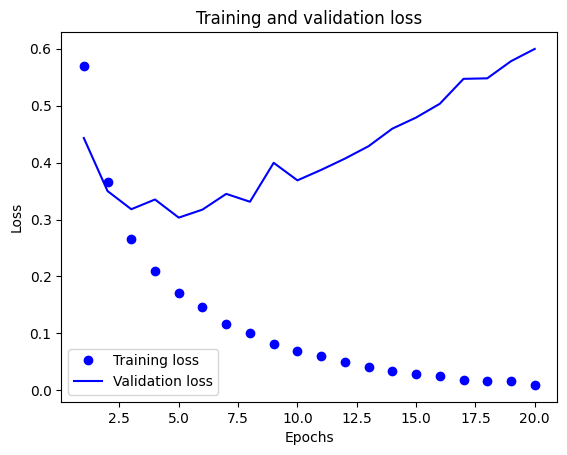

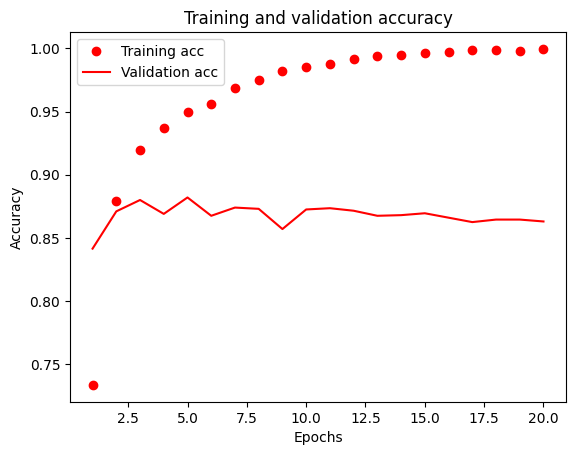

In [17]:
import matplotlib.pyplot as plt

history_dict = history.history


# Retrieve the values
loss = history_dict["loss"]
val_loss = history_dict["val_loss"]
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
epochs = range(1, len(loss) + 1)

# Trace la loss
plt.figure()
plt.plot(epochs, loss, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Trace l'accuracy
plt.figure()
plt.plot(epochs, acc, "ro", label="Training acc")
plt.plot(epochs, val_acc, "r", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [18]:
results = model.evaluate(X_test, y_test)
print(f"Test loss: {results[0]:.4f}")
print(f"Test accuracy: {results[1]*100:.2f}%")


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8635 - loss: 0.5479
Test loss: 0.5174
Test accuracy: 86.88%


- Retrain the model with an optimal number of epochs to avoid overfitting.
- Evaluate the final model on the test set to measure its performance.

In [19]:
model2 = Sequential()
model2.add(Dense(16, activation='relu', input_shape=(10000,)))
model2.add(Dense(16, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])


In [20]:
history = model2.fit(
    X_train_small, y_train_small,
    epochs=4,
    batch_size=512,
    validation_data=(X_val_small, y_val_small)
)


Epoch 1/4
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.6592 - loss: 0.6352 - val_accuracy: 0.8410 - val_loss: 0.4779
Epoch 2/4
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.8727 - loss: 0.4268 - val_accuracy: 0.8625 - val_loss: 0.3908
Epoch 3/4
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9051 - loss: 0.3161 - val_accuracy: 0.8775 - val_loss: 0.3265
Epoch 4/4
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - accuracy: 0.9245 - loss: 0.2516 - val_accuracy: 0.8825 - val_loss: 0.3083


In [21]:
results = model2.evaluate(X_test, y_test)
print(f"Test loss: {results[0]:.4f}")
print(f"Test accuracy: {results[1]*100:.2f}%")


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8786 - loss: 0.3050
Test loss: 0.2978
Test accuracy: 88.46%


### **5. Analyze Results:**

- Compare the training and validation metrics to understand the model’s behavior.
- Report the final accuracy and loss on the test set.


🔹 **Model 1** – Trained for 20 epochs (no early stopping)
- Test Loss: 0.5174
- Test Accuracy: 86.88%

The training loss decreased steadily, but the validation loss started increasing after epoch 4, indicating overfitting.

The model continued to improve on training data but failed to generalize as well to unseen data.

🔹 **Model 2** – Trained for 4 epochs (optimal based on validation curves)
- Test Loss: 0.2978
- Test Accuracy: 88.46%

Training was stopped early to prevent overfitting.

This led to a better generalization on the test set and higher accuracy compared to the overfitted model.

💡 **Conclusion**

Monitoring validation performance is crucial to avoid overfitting.

Stopping training at the right time significantly improves test performance.

This simple model (2 hidden layers with ReLU + sigmoid output) trained on one-hot encoded vectors performs surprisingly well on sentiment classification.

